# Notebook 10 — Leakage & Calibration Audit

Three concerns about the k=8 model (AUC 0.967):

1. **Target leakage — `elapsed_days`**: does the elapsed time at event 8 effectively encode total duration?
2. **Reminder leakage**: do `Send Reminder` events appear late enough in a case that their presence at k=8 announces "already delayed"?
3. **Calibration**: AUC measures discrimination, not reliability — does P(long)=0.8 actually mean 80%?

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap

ROOT         = Path.cwd().parent
T            = ROOT / 'outputs' / 'tables'
OUT          = ROOT / 'outputs' / 'figures'
LONG_THRESHOLD_DAYS = 101.1
PREFIX_K     = 8
RANDOM_STATE = 42
CV_FOLDS     = 5

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [2]:
from src.load_event_log import load_xes_log

log = load_xes_log(ROOT / 'data' / 'raw' / 'PermitLog.xes', legacy=True)

rows = []
for trace in log:
    cid    = trace.attributes.get('concept:name', '')
    dept   = trace.attributes.get('case:OrganizationalEntity', '')
    budget = trace.attributes.get('case:RequestedBudget', np.nan)
    for evt in trace:
        rows.append({
            'case_id':   cid,
            'activity':  str(evt['concept:name']),
            'timestamp': evt['time:timestamp'],
            'org':       str(evt.get('org:resource', '')),
            'dept':      dept,
            'budget':    budget,
        })

df = pd.DataFrame(rows)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_localize(None)
df = df.sort_values(['case_id', 'timestamp']).reset_index(drop=True)
df['event_idx'] = df.groupby('case_id').cumcount()   # 0-based position within case

case_starts = df.groupby('case_id')['timestamp'].min()
case_ends   = df.groupby('case_id')['timestamp'].max()
dur = (case_ends - case_starts).dt.total_seconds() / 86400
is_long = (dur >= LONG_THRESHOLD_DAYS).astype(int).rename('is_long')

print(f'{len(df):,} events, {df.case_id.nunique():,} cases')
print(f'Long cases (≥{LONG_THRESHOLD_DAYS}d): {is_long.sum():,} ({is_long.mean():.1%})')

parsing log, completed traces ::   0%|          | 0/7065 [00:00<?, ?it/s]

parsing log, completed traces ::  15%|█▍        | 1055/7065 [00:00<00:00, 10521.16it/s]

parsing log, completed traces ::  30%|██▉       | 2108/7065 [00:00<00:00, 9885.78it/s] 

parsing log, completed traces ::  44%|████▍     | 3100/7065 [00:00<00:00, 9204.11it/s]

parsing log, completed traces ::  57%|█████▋    | 4026/7065 [00:00<00:00, 9110.08it/s]

parsing log, completed traces ::  70%|██████▉   | 4940/7065 [00:00<00:00, 9109.87it/s]

parsing log, completed traces ::  83%|████████▎ | 5853/7065 [00:00<00:00, 8993.37it/s]

parsing log, completed traces ::  99%|█████████▊| 6967/7065 [00:00<00:00, 9665.89it/s]

parsing log, completed traces :: 100%|██████████| 7065/7065 [00:00<00:00, 9513.14it/s]

86,581 events, 7,065 cases
Long cases (≥101.1d): 2,355 (33.3%)


## Concern 2 — Reminder leakage: at what event position do reminders occur?

If `Send Reminder` first appears at event index 20+ in most cases, its presence at k=8 is genuine early signal.  
If it predominantly appears at positions 7–8 (i.e., it is often literally the last event in the prefix window), it is announcing "this case was already slow enough to need a reminder".

Cases with ≥1 Send Reminder: 1,381 (19.5%)
Cases where first reminder is WITHIN first 8 events: 1,184 (85.7%)

First reminder position (event index) — percentiles:
count    1381.0
mean        6.2
std         2.9
min         3.0
10%         5.0
25%         5.0
50%         5.0
75%         6.0
90%        10.0
max        34.0
Name: first_reminder_idx, dtype: float64

Median % through the case when first reminder occurs:
  71.4%


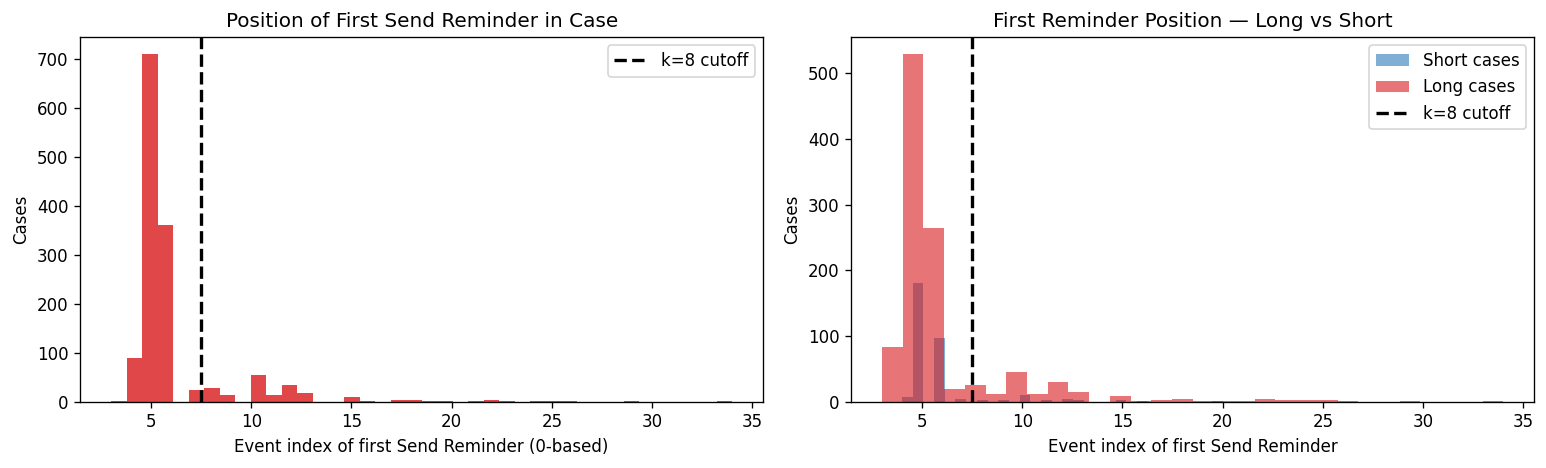

Saved leakage_reminder_position.png


In [3]:
reminders = df[df['activity'] == 'Send Reminder'].copy()
first_reminder = reminders.groupby('case_id')['event_idx'].min().reset_index()
first_reminder.columns = ['case_id', 'first_reminder_idx']
first_reminder['is_long'] = first_reminder['case_id'].map(is_long)

total_events_per_case = df.groupby('case_id').size().rename('n_events')
first_reminder = first_reminder.join(total_events_per_case, on='case_id')
first_reminder['reminder_pct_through'] = first_reminder['first_reminder_idx'] / first_reminder['n_events']

n_cases_with_reminder = len(first_reminder)
n_reminder_before_k8  = (first_reminder['first_reminder_idx'] < PREFIX_K).sum()
pct_before_k8         = n_reminder_before_k8 / n_cases_with_reminder

print(f'Cases with ≥1 Send Reminder: {n_cases_with_reminder:,} ({n_cases_with_reminder/7065:.1%})')
print(f'Cases where first reminder is WITHIN first {PREFIX_K} events: '
      f'{n_reminder_before_k8:,} ({pct_before_k8:.1%})')
print()
print('First reminder position (event index) — percentiles:')
print(first_reminder['first_reminder_idx'].describe(percentiles=[.1,.25,.5,.75,.9]).round(1))
print()
print('Median % through the case when first reminder occurs:')
print(f"  {first_reminder['reminder_pct_through'].median():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(first_reminder['first_reminder_idx'], bins=40, color='#d7191c', alpha=0.8)
axes[0].axvline(PREFIX_K - 0.5, color='black', linewidth=2, linestyle='--',
                label=f'k={PREFIX_K} cutoff')
axes[0].set_xlabel('Event index of first Send Reminder (0-based)')
axes[0].set_ylabel('Cases')
axes[0].set_title('Position of First Send Reminder in Case')
axes[0].legend()

long_rem  = first_reminder[first_reminder['is_long'] == 1]['first_reminder_idx']
short_rem = first_reminder[first_reminder['is_long'] == 0]['first_reminder_idx']
axes[1].hist(short_rem, bins=30, alpha=0.6, label='Short cases', color='#2c7bb6')
axes[1].hist(long_rem,  bins=30, alpha=0.6, label='Long cases',  color='#d7191c')
axes[1].axvline(PREFIX_K - 0.5, color='black', linewidth=2, linestyle='--',
                label=f'k={PREFIX_K} cutoff')
axes[1].set_xlabel('Event index of first Send Reminder')
axes[1].set_ylabel('Cases')
axes[1].set_title('First Reminder Position — Long vs Short')
axes[1].legend()

plt.tight_layout()
fig.savefig(OUT / 'leakage_reminder_position.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved leakage_reminder_position.png')

## Build prefix features — shared across all ablation experiments

In [4]:
act_enc = LabelEncoder().fit(df['activity'])

ACTS = [
    'Send Reminder', 'Declaration REJECTED by DIRECTOR',
    'Declaration REJECTED by EMPLOYEE', 'Declaration REJECTED by BUDGET OWNER',
    'Permit REJECTED by ADMINISTRATION', 'Permit REJECTED by BUDGET OWNER',
    'Permit REJECTED by PRE_APPROVER', 'Permit REJECTED by DIRECTOR',
    'Permit REJECTED by MISSING', 'Declaration APPROVED by DIRECTOR',
    'Declaration APPROVED by BUDGET OWNER', 'Declaration APPROVED by SUPERVISOR',
    'Permit APPROVED by BUDGET OWNER', 'Permit APPROVED by PRE_APPROVER',
    'Permit FINAL_APPROVED by SUPERVISOR',
]
flag_cols = [f"has_{a.replace(' ', '_').replace(':', '_')}" for a in ACTS]

def make_prefix_features(df, k):
    rows = []
    for cid, grp in df.groupby('case_id'):
        prefix = grp.head(k)
        t0      = prefix['timestamp'].iloc[0]
        elapsed = (prefix['timestamp'].iloc[-1] - t0).total_seconds() / 86400
        feats = {
            'case_id':           cid,
            'elapsed_days':      elapsed,
            'n_events_prefix':   len(prefix),
            'n_rejections':      prefix['activity'].str.contains('REJECTED').sum(),
            'n_reminders':       (prefix['activity'] == 'Send Reminder').sum(),
            'n_approvals':       prefix['activity'].str.contains('APPROVED').sum(),
            'first_act_enc':     act_enc.transform([prefix['activity'].iloc[0]])[0],
            'org_encoded':       hash(str(prefix['org'].iloc[-1])) % 1000,
            'budget':            prefix['budget'].iloc[0],
            'case_start_month':  t0.month,
            'case_start_dow':    t0.dayofweek,
        }
        acts_in = set(prefix['activity'])
        for act, col in zip(ACTS, flag_cols):
            feats[col] = int(act in acts_in)
        feats['is_long'] = is_long.get(cid, 0)
        rows.append(feats)
    return pd.DataFrame(rows)

feat_df   = make_prefix_features(df, PREFIX_K)
all_feats = [c for c in feat_df.columns if c not in ('case_id', 'is_long')]
feat_df   = feat_df.dropna(subset=all_feats, how='all').copy()

# Drop all-NaN columns before imputing
valid_feats = [c for c in all_feats if feat_df[c].notna().any()]
X_all = feat_df[valid_feats]
y     = feat_df['is_long'].values

print(f'Feature matrix: {X_all.shape}  |  long rate: {y.mean():.1%}')
print(f'Features: {valid_feats}')

Feature matrix: (7065, 24)  |  long rate: 33.3%
Features: ['elapsed_days', 'n_events_prefix', 'n_rejections', 'n_reminders', 'n_approvals', 'first_act_enc', 'org_encoded', 'case_start_month', 'case_start_dow', 'has_Send_Reminder', 'has_Declaration_REJECTED_by_DIRECTOR', 'has_Declaration_REJECTED_by_EMPLOYEE', 'has_Declaration_REJECTED_by_BUDGET_OWNER', 'has_Permit_REJECTED_by_ADMINISTRATION', 'has_Permit_REJECTED_by_BUDGET_OWNER', 'has_Permit_REJECTED_by_PRE_APPROVER', 'has_Permit_REJECTED_by_DIRECTOR', 'has_Permit_REJECTED_by_MISSING', 'has_Declaration_APPROVED_by_DIRECTOR', 'has_Declaration_APPROVED_by_BUDGET_OWNER', 'has_Declaration_APPROVED_by_SUPERVISOR', 'has_Permit_APPROVED_by_BUDGET_OWNER', 'has_Permit_APPROVED_by_PRE_APPROVER', 'has_Permit_FINAL_APPROVED_by_SUPERVISOR']


## Concern 1 — elapsed_days distribution: long vs short cases

Before training anything: does `elapsed_days` at k=8 visually separate the classes?  
If the two distributions barely overlap, the feature is almost the target — leakage.

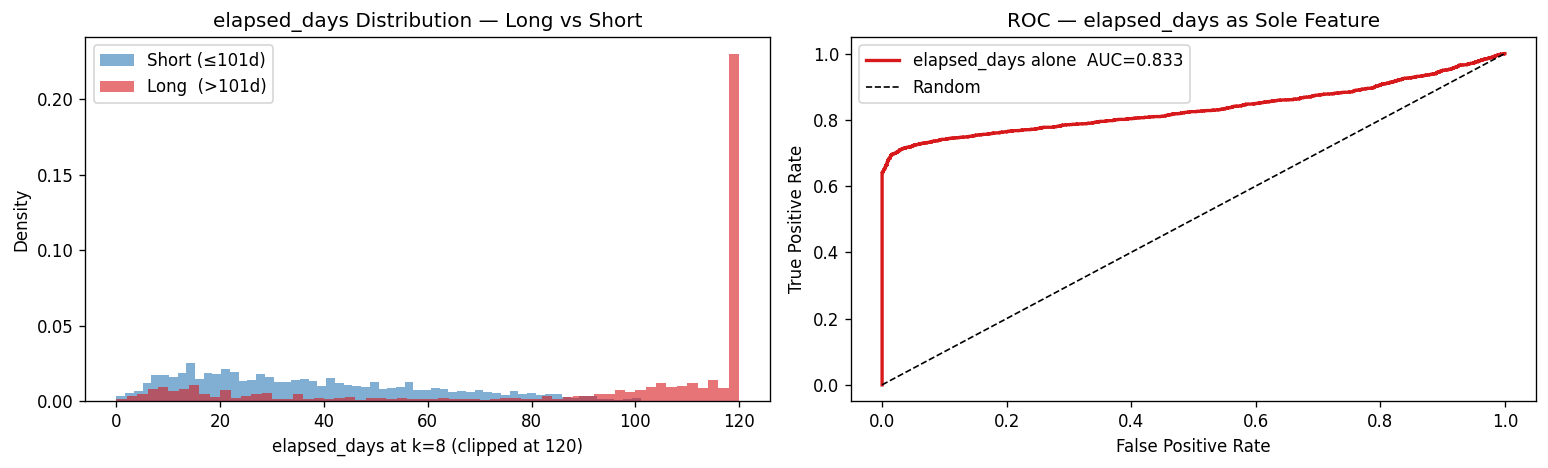


elapsed_days SOLO AUC at k=8: 0.833
  Long  cases — median elapsed_days: 114.6d
  Short cases — median elapsed_days: 32.9d

  82.5% of long cases have elapsed_days > median-short elapsed_days

⚠  elapsed_days alone achieves AUC > 0.70 — meaningful but not dominant leakage.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

el_long  = X_all.loc[y == 1, 'elapsed_days'].clip(upper=120)
el_short = X_all.loc[y == 0, 'elapsed_days'].clip(upper=120)

axes[0].hist(el_short, bins=60, alpha=0.6, label='Short (≤101d)', color='#2c7bb6', density=True)
axes[0].hist(el_long,  bins=60, alpha=0.6, label='Long  (>101d)', color='#d7191c', density=True)
axes[0].set_xlabel('elapsed_days at k=8 (clipped at 120)')
axes[0].set_ylabel('Density')
axes[0].set_title('elapsed_days Distribution — Long vs Short')
axes[0].legend()

# AUROC of elapsed_days alone as a single-feature classifier
from sklearn.metrics import roc_auc_score, roc_curve
el_vals = X_all['elapsed_days'].fillna(X_all['elapsed_days'].median()).values
solo_auc = roc_auc_score(y, el_vals)
fpr, tpr, _ = roc_curve(y, el_vals)
axes[1].plot(fpr, tpr, color='#d7191c', linewidth=2,
             label=f'elapsed_days alone  AUC={solo_auc:.3f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC — elapsed_days as Sole Feature')
axes[1].legend()

plt.tight_layout()
fig.savefig(OUT / 'leakage_elapsed_days_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nelapsed_days SOLO AUC at k={PREFIX_K}: {solo_auc:.3f}')
print(f'  Long  cases — median elapsed_days: {el_long.median():.1f}d')
print(f'  Short cases — median elapsed_days: {el_short.median():.1f}d')
print()
# Overlap check: what fraction of long cases have elapsed > median short?
overlap_pct = (el_long > el_short.median()).mean()
print(f'  {overlap_pct:.1%} of long cases have elapsed_days > median-short elapsed_days')
print()
if solo_auc > 0.85:
    print('⚠  elapsed_days alone achieves AUC > 0.85 — strong leakage signal.')
elif solo_auc > 0.70:
    print('⚠  elapsed_days alone achieves AUC > 0.70 — meaningful but not dominant leakage.')
else:
    print('✓  elapsed_days alone is not a strong predictor — limited leakage concern.')

## Ablation experiments — CV helper

Train the same XGBoost with stratified k-fold CV across four feature sets:
1. **Full** — all features
2. **No elapsed_days** — remove `elapsed_days` only
3. **No reminders** — remove `n_reminders` + `has_Send_Reminder`
4. **No elapsed + no reminders** — both removed simultaneously

In [6]:
def cv_auc(X_df, y, n_splits=CV_FOLDS):
    """Stratified k-fold AUC with median imputation per fold."""
    cv   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aucs = []
    for tr, te in cv.split(X_df, y):
        imp  = SimpleImputer(strategy='median')
        Xtr  = pd.DataFrame(imp.fit_transform(X_df.iloc[tr]), columns=X_df.columns)
        Xte  = pd.DataFrame(imp.transform(X_df.iloc[te]),     columns=X_df.columns)
        ytr, yte = y[tr], y[te]
        if len(np.unique(ytr)) < 2:
            continue
        m = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
        m.fit(Xtr, ytr)
        aucs.append(roc_auc_score(yte, m.predict_proba(Xte)[:,1]))
    return np.mean(aucs), np.std(aucs)

REMINDER_COLS = ['n_reminders', 'has_Send_Reminder']

ablations = {
    'Full':                    valid_feats,
    'No elapsed_days':         [f for f in valid_feats if f != 'elapsed_days'],
    'No reminders':            [f for f in valid_feats if f not in REMINDER_COLS],
    'No elapsed + no remind':  [f for f in valid_feats if f != 'elapsed_days'
                                 and f not in REMINDER_COLS],
}

results = []
for label, feats in ablations.items():
    print(f'Running: {label} ({len(feats)} features)...')
    mean_auc, std_auc = cv_auc(X_all[feats], y)
    results.append({'Model': label, 'n_features': len(feats),
                    'AUC_mean': mean_auc, 'AUC_std': std_auc})
    print(f'  AUC = {mean_auc:.3f} ± {std_auc:.3f}')

abl_df = pd.DataFrame(results)
print()
print(abl_df.to_string(index=False))

Running: Full (24 features)...


  AUC = 0.967 ± 0.004
Running: No elapsed_days (23 features)...


  AUC = 0.810 ± 0.009
Running: No reminders (22 features)...


  AUC = 0.967 ± 0.004
Running: No elapsed + no remind (21 features)...


  AUC = 0.805 ± 0.008

                 Model  n_features  AUC_mean  AUC_std
                  Full          24  0.967100 0.004368
       No elapsed_days          23  0.810039 0.009314
          No reminders          22  0.967187 0.004291
No elapsed + no remind          21  0.805407 0.007786


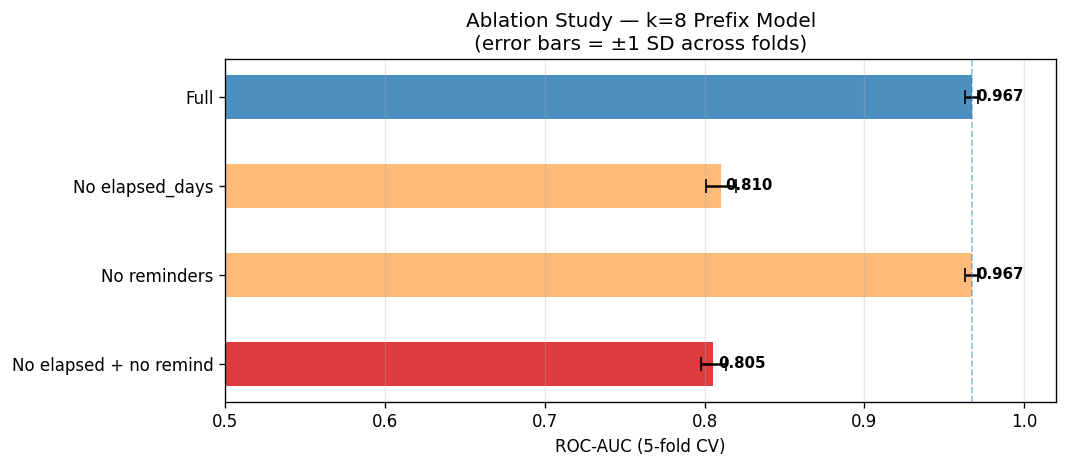

AUC drop removing elapsed_days only:      -0.157
AUC drop removing reminders only:         --0.000
AUC drop removing both:                   -0.162

Saved leakage_ablation_results.csv


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
labels  = abl_df['Model']
means   = abl_df['AUC_mean']
stds    = abl_df['AUC_std']
colors  = ['#2c7bb6', '#fdae61', '#fdae61', '#d7191c']

bars = ax.barh(labels[::-1], means[::-1], xerr=stds[::-1],
               color=colors[::-1], alpha=0.85, height=0.5,
               error_kw={'linewidth': 1.5, 'capsize': 4})
for bar, v in zip(bars, means[::-1]):
    ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0.5, 1.02)
ax.set_xlabel('ROC-AUC (5-fold CV)')
ax.set_title(f'Ablation Study — k={PREFIX_K} Prefix Model\n'
             '(error bars = ±1 SD across folds)')
ax.axvline(means[0], color='#2c7bb6', linewidth=1, linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(OUT / 'leakage_ablation_auc.png', dpi=150, bbox_inches='tight')
plt.show()

drop_elapsed = means[0] - means[1]
drop_remind  = means[0] - means[2]
drop_both    = means[0] - means[3]
print(f'AUC drop removing elapsed_days only:      -{drop_elapsed:.3f}')
print(f'AUC drop removing reminders only:         -{drop_remind:.3f}')
print(f'AUC drop removing both:                   -{drop_both:.3f}')
abl_df.to_csv(T / 'leakage_ablation_results.csv', index=False)
print('\nSaved leakage_ablation_results.csv')

## Concern 3 — Calibration: can we trust the probability scores?

Train a final model on 80% of the data, evaluate calibration on the held-out 20%.  
Report: calibration curve, Brier score, and compare raw XGBoost vs Platt-scaled version.

In [8]:
from sklearn.model_selection import train_test_split

imp_full = SimpleImputer(strategy='median')
X_imp    = pd.DataFrame(imp_full.fit_transform(X_all), columns=valid_feats)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_imp, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Raw XGBoost
xgb_raw = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
xgb_raw.fit(X_tr, y_tr)
prob_raw = xgb_raw.predict_proba(X_te)[:,1]

# Platt-scaled (sigmoid calibration)
xgb_cal = CalibratedClassifierCV(
    xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8,
                       eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    method='sigmoid', cv=3)
xgb_cal.fit(X_tr, y_tr)
prob_cal = xgb_cal.predict_proba(X_te)[:,1]

auc_raw = roc_auc_score(y_te, prob_raw)
auc_cal = roc_auc_score(y_te, prob_cal)
bs_raw  = brier_score_loss(y_te, prob_raw)
bs_cal  = brier_score_loss(y_te, prob_cal)

print('                  AUC     Brier')
print(f'Raw XGBoost:     {auc_raw:.3f}   {bs_raw:.4f}')
print(f'Platt-scaled:    {auc_cal:.3f}   {bs_cal:.4f}')
print()
print('Brier score: lower is better (0 = perfect, 0.25 = uninformative baseline)')

                  AUC     Brier
Raw XGBoost:     0.963   0.0662
Platt-scaled:    0.963   0.0692

Brier score: lower is better (0 = perfect, 0.25 = uninformative baseline)


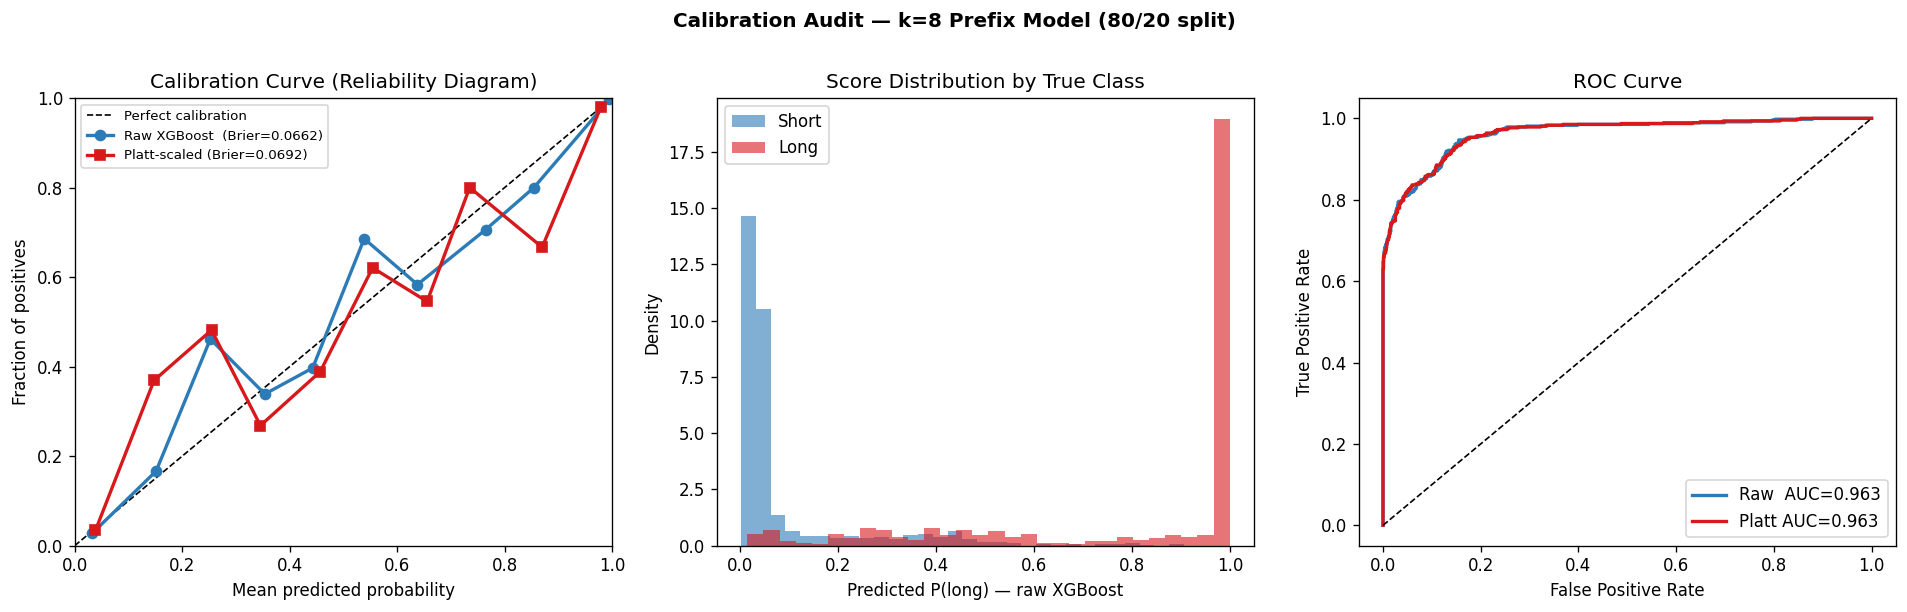

Saved leakage_calibration.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Calibration curves ─────────────────────────────────────────
frac_raw, mean_raw = calibration_curve(y_te, prob_raw, n_bins=10, strategy='uniform')
frac_cal, mean_cal = calibration_curve(y_te, prob_cal, n_bins=10, strategy='uniform')

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect calibration')
axes[0].plot(mean_raw, frac_raw, 'o-', color='#2c7bb6', linewidth=2,
             label=f'Raw XGBoost  (Brier={bs_raw:.4f})')
axes[0].plot(mean_cal, frac_cal, 's-', color='#d7191c', linewidth=2,
             label=f'Platt-scaled (Brier={bs_cal:.4f})')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives')
axes[0].set_title('Calibration Curve (Reliability Diagram)')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# ── Panel 2: Predicted probability histograms ───────────────────────────
axes[1].hist(prob_raw[y_te==0], bins=30, alpha=0.6, color='#2c7bb6', density=True, label='Short')
axes[1].hist(prob_raw[y_te==1], bins=30, alpha=0.6, color='#d7191c', density=True, label='Long')
axes[1].set_xlabel('Predicted P(long) — raw XGBoost')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution by True Class')
axes[1].legend()

# ── Panel 3: ROC comparison ─────────────────────────────────────────────
from sklearn.metrics import roc_curve
fpr_r, tpr_r, _ = roc_curve(y_te, prob_raw)
fpr_c, tpr_c, _ = roc_curve(y_te, prob_cal)
axes[2].plot(fpr_r, tpr_r, color='#2c7bb6', linewidth=2, label=f'Raw  AUC={auc_raw:.3f}')
axes[2].plot(fpr_c, tpr_c, color='#d7191c', linewidth=2, label=f'Platt AUC={auc_cal:.3f}')
axes[2].plot([0,1],[0,1], 'k--', linewidth=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend()

plt.suptitle(f'Calibration Audit — k={PREFIX_K} Prefix Model (80/20 split)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(OUT / 'leakage_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved leakage_calibration.png')

## Summary: verdict on all three concerns

In [10]:
full_auc   = abl_df.loc[abl_df['Model']=='Full', 'AUC_mean'].values[0]
no_el_auc  = abl_df.loc[abl_df['Model']=='No elapsed_days', 'AUC_mean'].values[0]
no_rem_auc = abl_df.loc[abl_df['Model']=='No reminders', 'AUC_mean'].values[0]
no_both    = abl_df.loc[abl_df['Model']=='No elapsed + no remind', 'AUC_mean'].values[0]

print('══════════════════════════════════════════════════════════')
print(f'  CONCERN 1 — elapsed_days target leakage')
print(f'    elapsed_days solo AUC:          {solo_auc:.3f}')
print(f'    Full model AUC (CV):            {full_auc:.3f}')
print(f'    Model without elapsed_days:     {no_el_auc:.3f}')
print(f'    AUC attributable to elapsed:   -{full_auc - no_el_auc:.3f}')
if solo_auc > 0.85:
    v1 = '⚠  CONFIRMED — elapsed_days partially encodes total duration'
elif solo_auc > 0.70:
    v1 = '⚠  PARTIAL — elapsed_days contributes meaningful but non-dominant leakage'
else:
    v1 = '✓  NOT confirmed — elapsed_days at k=8 is legitimate early signal'
print(f'    Verdict: {v1}')

print()
print(f'  CONCERN 2 — reminder leakage')
print(f'    Cases with reminder in first {PREFIX_K} events: {n_reminder_before_k8} ({pct_before_k8:.1%})')
print(f'    Full model AUC (CV):            {full_auc:.3f}')
print(f'    Model without reminder feats:   {no_rem_auc:.3f}')
print(f'    AUC attributable to reminders: -{full_auc - no_rem_auc:.3f}')
if pct_before_k8 > 0.20 and (full_auc - no_rem_auc) > 0.05:
    v2 = '⚠  CONFIRMED — reminders within k=8 are announcing past delay'
elif pct_before_k8 < 0.10:
    v2 = '✓  NOT confirmed — reminders rarely appear within first 8 events'
else:
    v2 = '~ BORDERLINE — some reminder leakage, monitor in deployment'
print(f'    Verdict: {v2}')

print()
print(f'  CONCERN 3 — calibration')
print(f'    Raw XGBoost  — AUC: {auc_raw:.3f}  Brier: {bs_raw:.4f}')
print(f'    Platt-scaled — AUC: {auc_cal:.3f}  Brier: {bs_cal:.4f}')
bs_baseline = y_te.mean() * (1 - y_te.mean())
print(f'    Brier baseline (predict class rate): {bs_baseline:.4f}')
bs_skill = 1 - bs_raw / bs_baseline
print(f'    Brier skill score (raw): {bs_skill:.3f}  (1=perfect, 0=no skill)')
if bs_raw < 0.10:
    v3 = '✓  Well calibrated — probabilities are reliable'
elif bs_raw < 0.15:
    v3 = '~ ACCEPTABLE — moderate miscalibration; Platt scaling improves it'
else:
    v3 = '⚠  POOR calibration — do not trust raw probabilities; use Platt scaling'
print(f'    Verdict: {v3}')
print('══════════════════════════════════════════════════════════')

# Save calibration metrics
pd.DataFrame([{
    'elapsed_solo_auc': solo_auc,
    'full_auc_cv': full_auc,
    'no_elapsed_auc_cv': no_el_auc,
    'no_reminders_auc_cv': no_rem_auc,
    'no_both_auc_cv': no_both,
    'pct_reminder_in_k8': pct_before_k8,
    'brier_raw': bs_raw,
    'brier_platt': bs_cal,
    'brier_skill': bs_skill,
    'auc_raw_holdout': auc_raw,
    'auc_platt_holdout': auc_cal,
}]).to_csv(T / 'leakage_calibration_summary.csv', index=False)
print('\nSaved leakage_calibration_summary.csv')

══════════════════════════════════════════════════════════
  CONCERN 1 — elapsed_days target leakage
    elapsed_days solo AUC:          0.833
    Full model AUC (CV):            0.967
    Model without elapsed_days:     0.810
    AUC attributable to elapsed:   -0.157
    Verdict: ⚠  PARTIAL — elapsed_days contributes meaningful but non-dominant leakage

  CONCERN 2 — reminder leakage
    Cases with reminder in first 8 events: 1184 (85.7%)
    Full model AUC (CV):            0.967
    Model without reminder feats:   0.967
    AUC attributable to reminders: --0.000
    Verdict: ~ BORDERLINE — some reminder leakage, monitor in deployment

  CONCERN 3 — calibration
    Raw XGBoost  — AUC: 0.963  Brier: 0.0662
    Platt-scaled — AUC: 0.963  Brier: 0.0692
    Brier baseline (predict class rate): 0.2222
    Brier skill score (raw): 0.702  (1=perfect, 0=no skill)
    Verdict: ✓  Well calibrated — probabilities are reliable
══════════════════════════════════════════════════════════

Saved leak